In [1]:
import os
import sys
from pathlib import Path

sys.path.insert(0, str(Path(os.environ['CONDA_PREFIX']).absolute() / 'nsight-compute-2025.2.1' / 'extras' / 'python')
                )

In [2]:
from ncu_occupancy import *

In [3]:
get_gpu_data(8, 6)

{'cc_major': 8,
 'cc_minor': 6,
 'sm_version': 'sm_86',
 'threads_per_warp': 32,
 'max_warps_per_sm': 48,
 'max_threads_per_sm': 1536,
 'max_thread_blocks_per_sm': 16,
 'block_barriers_per_sm': 16,
 'smem_per_sm': 102400,
 'max_shared_mem_per_block': 102400,
 'registers_per_sm': 65536,
 'max_regs_per_block': 65536,
 'max_regs_per_thread': 255,
 'reg_allocation_unit_size': 256,
 'reg_allocation_granularity': 'warp',
 'shared_mem_allocation_unit_size': 128,
 'warps_allocation_granularity': 4,
 'max_thread_block_size': 1024,
 'shared_mem_size_configs': [102400, 65536, 32768, 16384, 8192, 0],
 'warp_reg_allocation_granularities': [256]}

In [4]:
def compute(ccM, ccm, tpb, reg, smem = 16384):
    return OccupancyCalculator(ccM, ccm).get_sm_occupancy(OccupancyParameters(smem, tpb, reg, 0, 0))

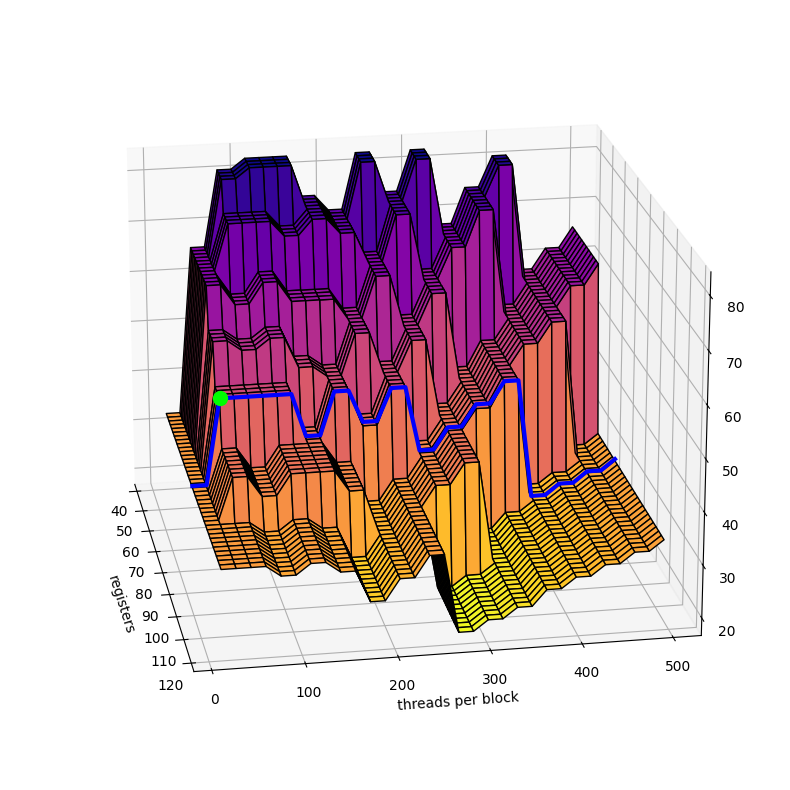

In [5]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

x_vals = np.array(list(range(42, 120, 2)))
y_vals = np.array(list(range(16, 512, 16)))
X, Y = np.meshgrid(x_vals, y_vals)

Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = compute(8, 6, int(Y[i, j]), int(X[i, j]))

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('registers')
ax.set_ylabel('threads per block')

POINT = (80, 48)

ax.plot([POINT[0]]*len(y_vals),
        y_vals,
        [compute(8, 6, int(x), POINT[0]) for x in y_vals],
        c='blue', linewidth=3,
        zorder=10)
ax.plot([POINT[0]], [POINT[1]], [compute(8, 6, POINT[1], POINT[0])], c='lime', zorder=100, marker='o', markersize=10)

ax.plot_surface(X, Y, Z, cmap='plasma_r', alpha=1, rstride=1, cstride=1, linewidth=1, edgecolors='k')

ax.view_init(20, 90+80+180, 0)
plt.show()

In [6]:
import plotly.graph_objects as go

POINT = (80, 48)

fig = go.Figure()

fig.add_trace(go.Surface(x=X, y=Y, z=Z, colorscale='Plasma_r',
                         showscale=False))

line_z = [compute(8, 6, int(x), POINT[0]) for x in y_vals]
fig.add_trace(go.Scatter3d(x=[POINT[0]]*len(y_vals), y=y_vals, z=line_z,
                           mode='lines',
                           line=dict(color='blue', width=7)))

point_z = compute(8, 6, POINT[1], POINT[0])
fig.add_trace(go.Scatter3d(x=[POINT[0]], y=[POINT[1]], z=[point_z],
                           mode='markers',
                           marker=dict(color='lime', size=10, symbol='circle')))

# Update the layout
fig.update_layout(
    title='3D Plot',
    scene=dict(
        xaxis_title='registers',
        yaxis_title='threads per block',
        zaxis_title='Z Value',
        camera=dict(
            eye=dict(x=-1.5, y=-1.5, z=0.5)
        )
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

In [ ]:
fig.write_image(Path().resolve().parent / 'data' / 'pubblications' / 'cc_plot.png')